# LactAnalytics · Análisis Exploratorio de Datos (EDA)
## Exploración inicial del dataset ENSE 2017

**Fuente:** Encuesta Nacional de Salud de España 2017 · Ministerio de Sanidad / INE  
**Autor:** Adriana Arang · Bootcamp IA & Big Data · F5 · 2025  
**Dataset:** `data/processed/lactancia_clean.csv` (generado por `src/data_loader.py`)

---
Este notebook documenta la exploración inicial del dataset limpio de lactancia materna.  
Cubre: dimensiones, tipos, nulos, distribuciones y primeras observaciones.

In [1]:
# ── Imports y configuración ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.family"]    = "DejaVu Sans"
COLORES = {"azul": "#648A96", "rosa": "#E8B8B8", "oscuro": "#1A2E35",
           "rojo": "#C0392B", "crema": "#F6F0E6"}

# Ruta al dataset procesado
DATA_PATH = Path("..") / "data" / "processed" / "lactancia_clean.csv"
df = pd.read_csv(DATA_PATH)

# Restaurar booleanos que se guardaron como string
for col in ["lactancia_materna", "lactancia_exclusiva",
            "lactancia_artificial", "lme_6meses", "lm_24meses"]:
    if col in df.columns:
        df[col] = df[col].map({"True": True, "False": False,
                                True: True, False: False})

print(f"✓ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head()

✓ Dataset cargado: 1,764 filas × 27 columnas


,id_hogar,ccaa_cod,sexo_menor,edad_menor,lactancia_materna,meses_lactancia_total,lactancia_exclusiva,meses_lactancia_excl,lactancia_artificial,meses_inicio_artificial,...,clase_social_label,ccaa,lme_6meses,lm_24meses,nivel_educativo_cod,ingresos_hogar_cod,fuente_ingresos,nivel_educativo,nivel_educativo_grupo,ingresos_hogar
0,1131,16,Niño,2,True,14.0,True,6.0,False,NaN,...,Clase I (directivos/profesionales),País Vasco,True,False,9.0,,,Posgrado,Universidad,NaN
1,6061,16,Niña,1,False,NaN,NaN,NaN,True,0.0,...,Clase VI (trabajadores no cualificados agrarios),País Vasco,False,False,5.0,03,,Secundaria 2ª etapa,Secundaria,1.000 – 1.499€
2,6101,16,Niño,2,True,10.0,True,1.0,True,1.0,...,Clase VI (trabajadores no cualificados agrarios),País Vasco,False,False,4.0,05,,Secundaria 1ª etapa,Secundaria,2.000 – 2.499€
3,12061,16,Niña,0,True,10.0,True,6.0,False,NaN,...,Clase V (trabajadores manuales no cualificados),País Vasco,True,False,8.0,,,Universitaria,Universidad,NaN
4,12121,16,Niño,2,True,2.0,True,2.0,True,0.0,...,Clase VI (trabajadores no cualificados agrarios),País Vasco,False,False,4.0,03,,Secundaria 1ª etapa,Secundaria,1.000 – 1.499€


## 1. Dimensiones y tipos de variables

In [2]:
# Dimensiones
print(f"Filas:    {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print()

# Tipos
tipos = df.dtypes.reset_index()
tipos.columns = ["Variable", "Tipo"]
tipos["Categoría"] = tipos["Tipo"].apply(
    lambda t: "Numérica"   if t in ["float64","int64"] else
              "Booleana"   if t == "bool"               else "Categórica"
)
print(tipos.to_string(index=False))

Filas:    1,764
Columnas: 27

               Variable    Tipo  Categoría
               id_hogar   int64   Numérica
               ccaa_cod   int64   Numérica
             sexo_menor  object Categórica
             edad_menor   int64   Numérica
      lactancia_materna    bool   Booleana
  meses_lactancia_total float64   Numérica
    lactancia_exclusiva  object Categórica
   meses_lactancia_excl float64   Numérica
   lactancia_artificial  object Categórica
meses_inicio_artificial float64   Numérica
       valoracion_salud   int64   Numérica
     enfermedad_cronica   int64   Numérica
                peso_kg   int64   Numérica
               talla_cm float64   Numérica
                    imc float64   Numérica
           clase_social float64   Numérica
            factor_peso float64   Numérica
     clase_social_label  object Categórica
                   ccaa  object Categórica
             lme_6meses    bool   Booleana
             lm_24meses    bool   Booleana
    nivel_educativo_cod 

In [3]:
# Resumen estadístico de variables numéricas
df.describe(include="number").round(2)

,id_hogar,ccaa_cod,edad_menor,meses_lactancia_total,meses_lactancia_excl,meses_inicio_artificial,valoracion_salud,enfermedad_cronica,peso_kg,talla_cm,imc,clase_social,factor_peso,nivel_educativo_cod
count,1764.00,1764.00,1764.00,1282.00,1208.00,1212.00,1764.00,1764.00,1764.00,126.00,957.00,1622.00,1764.00,1758.00
mean,1209688.98,8.97,2.14,9.01,4.19,4.05,1.50,1.97,1.93,1.21,2.24,3.69,1207.41,7.09
std,733968.31,5.14,1.36,8.60,1.92,3.96,0.66,0.42,0.26,0.75,1.00,1.64,759.29,7.15
min,1131.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,0.00,1.00,1.00,80.26,2.00
25%,581118.50,4.00,1.00,3.00,3.00,0.00,1.00,2.00,2.00,1.00,2.00,2.00,688.14,5.00
50%,1198061.00,9.00,2.00,6.00,5.00,3.00,1.00,2.00,2.00,1.00,2.00,4.00,1001.56,6.00
75%,1817591.00,13.00,3.00,12.00,6.00,6.00,2.00,2.00,2.00,1.00,3.00,5.00,1634.77,9.00
max,2499091.00,19.00,4.00,36.00,6.00,12.00,5.00,9.00,2.00,6.00,4.00,6.00,5317.38,98.00


## 2. Análisis de valores nulos

In [4]:
# Tabla de nulos
nulos = df.isnull().sum().reset_index()
nulos.columns = ["Variable", "N_nulos"]
nulos["pct_nulos"] = (nulos["N_nulos"] / len(df) * 100).round(1)
nulos = nulos[nulos["N_nulos"] > 0].sort_values("pct_nulos", ascending=False)
print(nulos.to_string(index=False))

               Variable  N_nulos  pct_nulos
               talla_cm     1638       92.9
         ingresos_hogar      975       55.3
                    imc      807       45.7
   meses_lactancia_excl      556       31.5
meses_inicio_artificial      552       31.3
  meses_lactancia_total      482       27.3
    lactancia_exclusiva      340       19.3
           clase_social      142        8.0
     clase_social_label      142        8.0
  nivel_educativo_grupo       16        0.9
   lactancia_artificial       11        0.6
    nivel_educativo_cod        6        0.3
        nivel_educativo        6        0.3


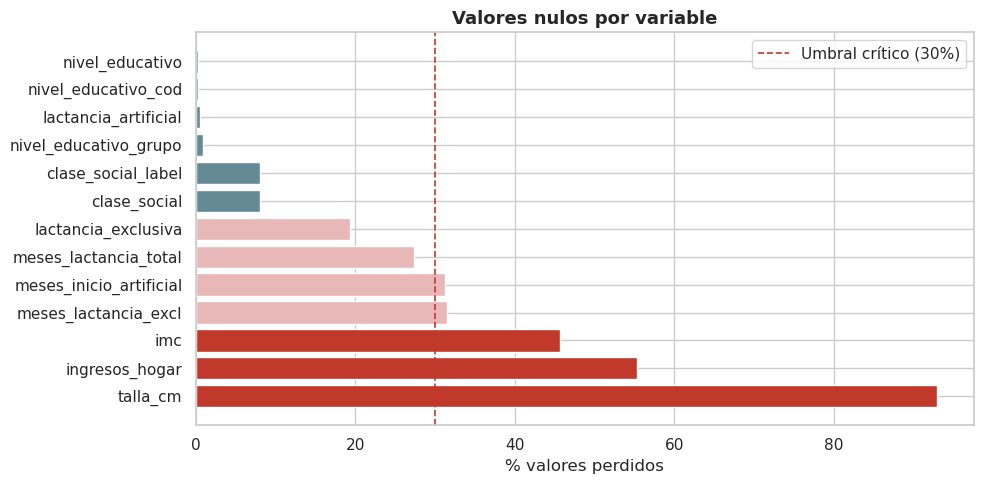


🔴 Crítico (>40%): talla_cm, ingresos_hogar, IMC
🟡 Relevante (>15%): meses LME, meses LM total
🟢 Aceptable (<15%): resto de variables


In [5]:
# Visualización de nulos
fig, ax = plt.subplots(figsize=(10, 5))
colores_barras = [COLORES["rojo"] if v > 40 else
                  COLORES["rosa"] if v > 15 else
                  COLORES["azul"] for v in nulos["pct_nulos"]]

ax.barh(nulos["Variable"], nulos["pct_nulos"], color=colores_barras)
ax.axvline(30, color=COLORES["rojo"], linestyle="--", linewidth=1.2,
           label="Umbral crítico (30%)")
ax.set_xlabel("% valores perdidos")
ax.set_title("Valores nulos por variable", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("../docs/nulos_por_variable.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n🔴 Crítico (>40%): talla_cm, ingresos_hogar, IMC")
print("🟡 Relevante (>15%): meses LME, meses LM total")
print("🟢 Aceptable (<15%): resto de variables")

## 3. Variables clave de lactancia

In [7]:
# Distribución de lactancia materna
print("=== L64: ¿Recibió lactancia materna? ===")
print(df["lactancia_materna"].value_counts(dropna=False))
print(f"\n% que recibió LM: {df['lactancia_materna'].mean()*100:.1f}%")

=== L64: ¿Recibió lactancia materna? ===
lactancia_materna
True     1431
False     333
Name: count, dtype: int64

% que recibió LM: 81.1%


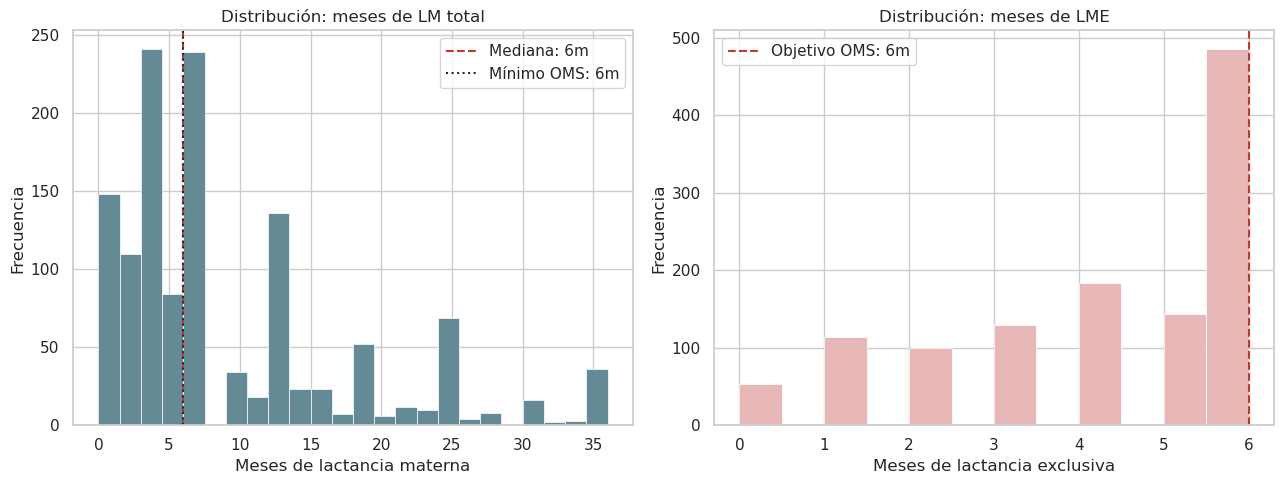

In [8]:
# Distribución de meses de lactancia total
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma
axes[0].hist(df["meses_lactancia_total"].dropna(), bins=24,
             color=COLORES["azul"], edgecolor="white", linewidth=0.5)
axes[0].axvline(df["meses_lactancia_total"].median(), color=COLORES["rojo"],
                linestyle="--", label=f"Mediana: {df['meses_lactancia_total'].median():.0f}m")
axes[0].axvline(6, color=COLORES["oscuro"], linestyle=":",
                label="Mínimo OMS: 6m")
axes[0].set_xlabel("Meses de lactancia materna")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución: meses de LM total")
axes[0].legend()

# Histograma LME
axes[1].hist(df["meses_lactancia_excl"].dropna(), bins=12,
             color=COLORES["rosa"], edgecolor="white", linewidth=0.5)
axes[1].axvline(6, color=COLORES["rojo"], linestyle="--",
                label="Objetivo OMS: 6m")
axes[1].set_xlabel("Meses de lactancia exclusiva")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución: meses de LME")
axes[1].legend()

plt.tight_layout()
plt.savefig("../docs/distribucion_lactancia.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# KPIs principales
total = len(df)
pct_lm    = df["lactancia_materna"].sum() / total * 100
pct_lme6  = df["lme_6meses"].sum()  / df["lme_6meses"].notna().sum()  * 100
pct_lm24  = df["lm_24meses"].sum()  / df["lm_24meses"].notna().sum()  * 100
media_lm  = df["meses_lactancia_total"].mean()
media_lme = df["meses_lactancia_excl"].mean()

print("═" * 45)
print(f"  Total menores en muestra:      {total:,}")
print(f"  % recibió LM:                  {pct_lm:.1f}%")
print(f"  % LME ≥ 6 meses (OMS):         {pct_lme6:.1f}%   ← objetivo: 100%")
print(f"  % LM ≥ 24 meses (OMS):         {pct_lm24:.1f}%   ← objetivo: 100%")
print(f"  Media duración LM:             {media_lm:.1f} meses")
print(f"  Media duración LME:            {media_lme:.1f} meses")
print(f"  Brecha LME vs OMS:             -{6-media_lme:.1f} meses")
print(f"  Brecha LM vs OMS:              -{24-media_lm:.1f} meses")
print("═" * 45)

## 4. Variables socioeconómicas

In [9]:
# Distribución por CCAA
ccaa_counts = df["ccaa"].value_counts()
print(f"CCAA con n < 30: {(ccaa_counts < 30).sum()} comunidades")
print()
print(ccaa_counts.to_string())

CCAA con n < 30: 1 comunidades

ccaa
Andalucía             253
Madrid                199
Cataluña              195
C. Valenciana         158
Galicia               107
País Vasco            105
Castilla y León        93
Murcia                 87
Baleares               86
Canarias               74
Castilla-La Mancha     68
Aragón                 61
La Rioja               58
Asturias               49
Extremadura            47
Navarra                38
Cantabria              32
Ceuta                  30
Melilla                24


In [ ]:
# Distribución por nivel educativo y clase social
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Nivel educativo
orden_educ = ["Básico o menos", "Secundaria", "FP", "Universidad"]
educ_counts = df["nivel_educativo_grupo"].value_counts()[orden_educ]
axes[0].bar(educ_counts.index, educ_counts.values,
            color=[COLORES["rojo"], COLORES["rosa"], COLORES["azul"], COLORES["oscuro"]])
axes[0].set_title("Distribución por nivel educativo")
axes[0].set_ylabel("N menores")
axes[0].tick_params(axis="x", rotation=15)

# Clase social
clase_labels = {1:"I·Alta", 2:"II·M-alta", 3:"III·Media",
                4:"IV·M-baja", 5:"V·Baja", 6:"VI·Agraria"}
sub_clase = df[df["clase_social"].notna() & df["clase_social"].isin(clase_labels.keys())].copy()
sub_clase["clase_label"] = sub_clase["clase_social"].astype(int).map(clase_labels)
clase_counts = sub_clase["clase_label"].value_counts()[list(clase_labels.values())]
axes[1].bar(clase_counts.index, clase_counts.values, color=COLORES["azul"])
axes[1].set_title("Distribución por clase social")
axes[1].set_ylabel("N menores")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("../docs/distribucion_socioeconomica.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Primeras observaciones y hallazgos

In [10]:
# LME por nivel educativo — primera exploración
tasa_lme_educ = (
    df[df["lme_6meses"].notna()]
    .groupby("nivel_educativo_grupo")["lme_6meses"]
    .agg(n="count", lme6=lambda x: x.sum())
    .assign(pct=lambda d: (d["lme6"]/d["n"]*100).round(1))
)
print("=== % LME ≥ 6m por nivel educativo ===")
print(tasa_lme_educ[["n","lme6","pct"]].to_string())

# LME por CCAA — top 5 y bottom 5
tasa_lme_ccaa = (
    df[df["lme_6meses"].notna()]
    .groupby("ccaa")["lme_6meses"]
    .agg(n="count", lme6=lambda x: x.sum())
    .assign(pct=lambda d: (d["lme6"]/d["n"]*100).round(1))
    .sort_values("pct", ascending=False)
)
print("\n=== Top 5 CCAA por LME ≥ 6m ===")
print(tasa_lme_ccaa.head(5).to_string())
print("\n=== Bottom 5 CCAA por LME ≥ 6m ===")
print(tasa_lme_ccaa.tail(5).to_string())

=== % LME ≥ 6m por nivel educativo ===
                         n  lme6   pct
nivel_educativo_grupo                 
Básico o menos          84    15  17.9
FP                     395   102  25.8
Secundaria             569   149  26.2
Universidad            700   214  30.6

=== Top 5 CCAA por LME ≥ 6m ===
                      n  lme6   pct
ccaa                               
Castilla y León      93    36  38.7
Castilla-La Mancha   68    26  38.2
Madrid              199    72  36.2
Navarra              38    13  34.2
Extremadura          47    16  34.0

=== Bottom 5 CCAA por LME ≥ 6m ===
             n  lme6   pct
ccaa                      
Asturias    49    10  20.4
Galicia    107    18  16.8
Cantabria   32     3   9.4
Melilla     24     2   8.3
Ceuta       30     1   3.3


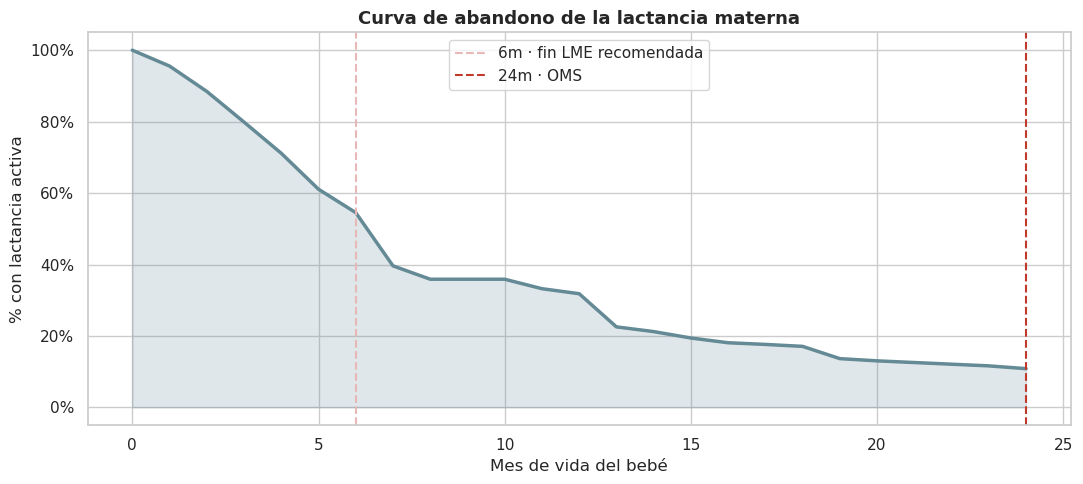

A los 6 meses: 54.5% siguen con LM
A los 12 meses: 31.8% siguen con LM
A los 24 meses: 10.8% siguen con LM


In [11]:
# Curva de abandono — primera exploración
sub_lm = df[df["meses_lactancia_total"].notna() & (df["lactancia_materna"]==True)]
total_lm = len(sub_lm)

meses = list(range(0, 25))
pct_activos = [(sub_lm["meses_lactancia_total"] >= m).sum() / total_lm * 100
               for m in meses]

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(meses, pct_activos, alpha=0.2, color=COLORES["azul"])
ax.plot(meses, pct_activos, color=COLORES["azul"], linewidth=2.5)
ax.axvline(6,  color=COLORES["rosa"],  linestyle="--", label="6m · fin LME recomendada")
ax.axvline(24, color=COLORES["rojo"],  linestyle="--", label="24m · OMS")
ax.set_xlabel("Mes de vida del bebé")
ax.set_ylabel("% con lactancia activa")
ax.set_title("Curva de abandono de la lactancia materna", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
plt.tight_layout()
plt.savefig("../docs/curva_abandono.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"A los 6 meses: {pct_activos[6]:.1f}% siguen con LM")
print(f"A los 12 meses: {pct_activos[12]:.1f}% siguen con LM")
print(f"A los 24 meses: {pct_activos[24]:.1f}% siguen con LM")

## 6. Conclusiones del EDA

| Hallazgo | Valor | Referencia OMS |
|---|---|---|
| % inició LM | 81.1% | Promover al 100% |
| % LME ≥ 6 meses | 27.5% | 100% |
| % LM ≥ 24 meses | 7.9% | 100% |
| Media duración LM | 9.0 meses | ≥ 24 meses |
| Media duración LME | 4.2 meses | ≥ 6 meses |

**Variables con limitaciones graves:**
- `talla_cm`: 92.9% nulos — no usable
- `ingresos_hogar`: 55.3% nulos — usar con precaución
- `imc`: 45.7% nulos — limitado

**Siguientes pasos:** ver `02_analisis_estadistico.ipynb`